# Tổng Quan Kết Quả AI — ECG Arrhythmia Detection

Notebook tổng hợp **toàn bộ kết quả AI/ML** đã đạt được trong dự án, đi kèm biểu đồ trực quan
(có đánh dấu từng điểm dữ liệu thật, không chỉ vẽ cột trung bình) để dễ đối chiếu và trình bày
khi bảo vệ. Toàn bộ số liệu được chép lại **chính xác** từ các báo cáo đã kiểm chứng
(`docs/benchmark_results.md`, `docs/onnx_comparison.md`, `docs/ai_process_summary.md`, `plan.md`)
— không đoán/ước lượng.

Không bao gồm phần triển khai hạ tầng (Docker/Nginx/Cloudflare/CI-CD) — chỉ tập trung vào AI.

**Mục lục**:
1. Dữ liệu & tiền xử lý
2. Benchmark 5 kiến trúc — chọn ResNet1D
3. Sửa lỗi rò rỉ dữ liệu Validation
4. Ma trận nhầm lẫn — đánh giá end-to-end
5. Phát hiện đỉnh R (QRS) — Pan-Tompkins
6. Xuất mô hình nhẹ — ONNX FP32/INT8
7. Sàng lọc rung nhĩ (AFib) — nợ kỹ thuật
8. Generalization ngoài MIT-BIH (INCART/SVDB/EDB)
9. Fine-tune INCART — 3 lần thử
10. Fine-tune SVDB — 2 lần thử (đều thất bại, có giá trị khoa học)
11. Tổng kết giới hạn


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from IPython.display import Image, display

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["font.size"] = 10

def scatter_line(ax, x_labels, series, title, ylabel, ylim=None, fmt="{:.1f}"):
    """Vẽ line+marker cho nhiều series, có ghi số ngay tại từng điểm dữ liệu thật."""
    x = np.arange(len(x_labels))
    for label, values, color in series:
        ax.plot(x, values, marker="o", markersize=7, linewidth=1.8, label=label, color=color)
        for xi, yi in zip(x, values):
            if yi is not None and not (isinstance(yi, float) and np.isnan(yi)):
                ax.annotate(fmt.format(yi), (xi, yi), textcoords="offset points",
                            xytext=(0, 7), ha="center", fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels(x_labels)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    if ylim:
        ax.set_ylim(*ylim)
    ax.legend(fontsize=8)


## 1. Dữ liệu & tiền xử lý

| Nguồn | Vai trò |
|---|---|
| Kaggle MIT-BIH CSV (187 điểm/nhịp, 5 lớp AAMI) | Huấn luyện & benchmark kiến trúc |
| PhysioNet MIT-BIH WFDB (tín hiệu thô 360Hz) | R-peak thật, kiểm chứng end-to-end, XAI, demo stream |

- Train gốc **mất cân bằng nặng** (N > 82%) → **SMOTE** cân bằng lại **chỉ trên Train**
  (72.471 mẫu/lớp), Test giữ nguyên phân phối thật.
- Validation (10%, stratified) được tách **trước SMOTE** (bài học từ mục 3 bên dưới).


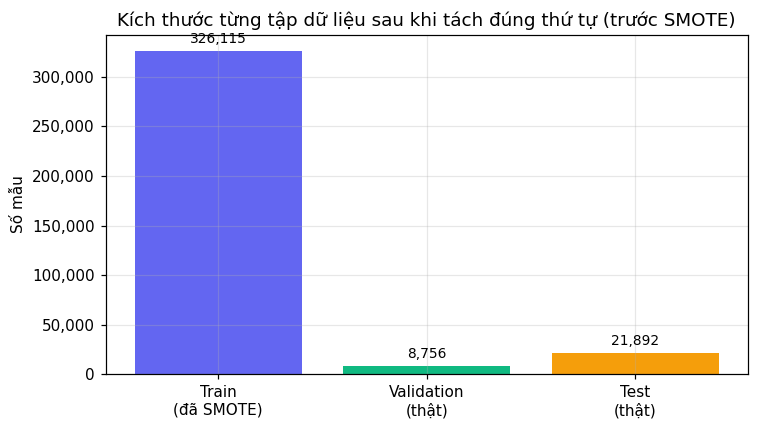

In [2]:
splits = ["Train\n(đã SMOTE)", "Validation\n(thật)", "Test\n(thật)"]
n_samples = [326115, 8756, 21892]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(splits, n_samples, color=["#6366f1", "#10b981", "#f59e0b"])
ax.set_ylabel("Số mẫu")
ax.set_title("Kích thước từng tập dữ liệu sau khi tách đúng thứ tự (trước SMOTE)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
for b, v in zip(bars, n_samples):
    ax.annotate(f"{v:,}", (b.get_x() + b.get_width()/2, v), textcoords="offset points",
                xytext=(0, 5), ha="center", fontsize=9)
fig.tight_layout()
plt.show()


## 2. Benchmark 5 kiến trúc Deep Learning 1D — vì sao chọn ResNet1D

Từng model là 1 điểm dữ liệu độc lập (huấn luyện + đánh giá riêng trên cùng 1 tập Test) —
biểu đồ scatter dưới đây đặt **Accuracy** và **Latency suy luận** trên 2 trục để thấy rõ
ResNet1D vừa chính xác nhất vừa nhanh nhất, không đánh đổi.


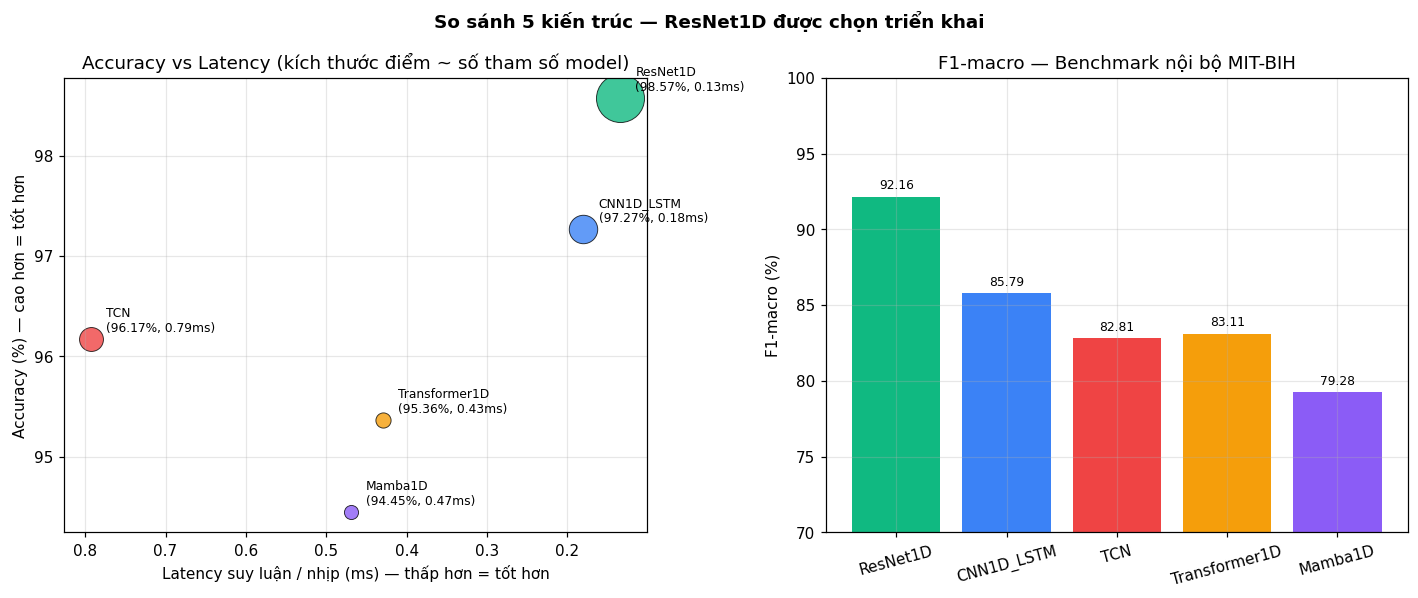

Model              Acc%     F1%   Latency(ms)      Params
ResNet1D          98.57   92.16        0.1342     692,389
CNN1D_LSTM        97.27   85.79        0.1800     242,885
TCN               96.17   82.81        0.7930     171,365
Transformer1D     95.36   83.11        0.4294      69,317
Mamba1D           94.45   79.28        0.4696      59,877


In [3]:
models = ["ResNet1D", "CNN1D_LSTM", "TCN", "Transformer1D", "Mamba1D"]
accuracy   = [98.57, 97.27, 96.17, 95.36, 94.45]
f1_macro   = [92.16, 85.79, 82.81, 83.11, 79.28]
latency_ms = [0.1342, 0.18, 0.793, 0.4294, 0.4696]
params     = [692389, 242885, 171365, 69317, 59877]
colors     = ["#10b981", "#3b82f6", "#ef4444", "#f59e0b", "#8b5cf6"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

# --- scatter: Accuracy vs Latency, kich thuoc diem = so tham so ---
sizes = [p / 700 for p in params]
for name, acc, lat, sz, c in zip(models, accuracy, latency_ms, sizes, colors):
    ax1.scatter(lat, acc, s=sz, color=c, alpha=0.8, edgecolor="black", linewidth=0.6, label=name)
    ax1.annotate(f"{name}\n({acc:.2f}%, {lat:.2f}ms)", (lat, acc), textcoords="offset points",
                 xytext=(10, 5), fontsize=8)
ax1.set_xlabel("Latency suy luận / nhịp (ms) — thấp hơn = tốt hơn")
ax1.set_ylabel("Accuracy (%) — cao hơn = tốt hơn")
ax1.set_title("Accuracy vs Latency (kích thước điểm ~ số tham số model)")
ax1.invert_xaxis()

# --- bar F1-macro cho tung model, danh dau gia tri that ---
x = np.arange(len(models))
bars = ax2.bar(x, f1_macro, color=colors)
ax2.set_xticks(x)
ax2.set_xticklabels(models, rotation=15)
ax2.set_ylabel("F1-macro (%)")
ax2.set_ylim(70, 100)
ax2.set_title("F1-macro — Benchmark nội bộ MIT-BIH")
for b, v in zip(bars, f1_macro):
    ax2.annotate(f"{v:.2f}", (b.get_x() + b.get_width()/2, v), textcoords="offset points",
                 xytext=(0, 5), ha="center", fontsize=8)

fig.suptitle("So sánh 5 kiến trúc — ResNet1D được chọn triển khai", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

print(f"{'Model':<15}{'Acc%':>8}{'F1%':>8}{'Latency(ms)':>14}{'Params':>12}")
for m, a, f, l, p in zip(models, accuracy, f1_macro, latency_ms, params):
    print(f"{m:<15}{a:>8.2f}{f:>8.2f}{l:>14.4f}{p:>12,}")


## 3. Sửa lỗi rò rỉ dữ liệu khi tách Validation

Lần đầu tách Validation **sau** SMOTE → mẫu tổng hợp lọt cả 2 tập → Val Accuracy bị thổi phồng
giả tạo. Biểu đồ dưới dùng đúng số liệu console log thật của 2 lần train (10 epoch mỗi lần),
mỗi điểm tròn là 1 epoch thật.


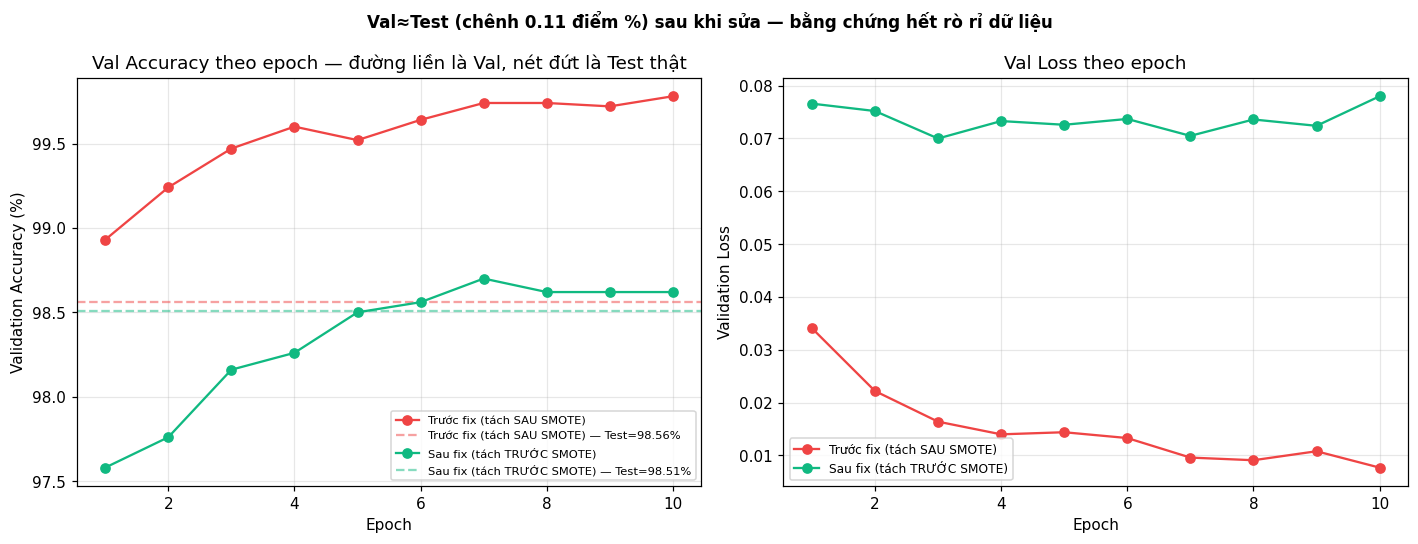

In [4]:
epochs = list(range(1, 11))
before = dict(
    val_acc=[98.93, 99.24, 99.47, 99.60, 99.52, 99.64, 99.74, 99.74, 99.72, 99.78],
    val_loss=[0.0341, 0.0222, 0.0164, 0.0140, 0.0144, 0.0133, 0.0096, 0.0091, 0.0108, 0.0077],
    test_acc=98.56, label="Trước fix (tách SAU SMOTE)", color="#ef4444",
)
after = dict(
    val_acc=[97.58, 97.76, 98.16, 98.26, 98.50, 98.56, 98.70, 98.62, 98.62, 98.62],
    val_loss=[0.0766, 0.0752, 0.0700, 0.0733, 0.0726, 0.0737, 0.0705, 0.0736, 0.0724, 0.0780],
    test_acc=98.51, label="Sau fix (tách TRƯỚC SMOTE)", color="#10b981",
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for run in (before, after):
    ax1.plot(epochs, run["val_acc"], marker="o", color=run["color"], label=run["label"])
    ax1.axhline(run["test_acc"], color=run["color"], linestyle="--", alpha=0.5,
                label=f"{run['label']} — Test={run['test_acc']}%")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Validation Accuracy (%)")
ax1.set_title("Val Accuracy theo epoch — đường liền là Val, nét đứt là Test thật")
ax1.legend(fontsize=7.5, loc="lower right")

for run in (before, after):
    ax2.plot(epochs, run["val_loss"], marker="o", color=run["color"], label=run["label"])
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Validation Loss")
ax2.set_title("Val Loss theo epoch")
ax2.legend(fontsize=8)

fig.suptitle("Val≈Test (chênh 0.11 điểm %) sau khi sửa — bằng chứng hết rò rỉ dữ liệu",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()


## 4. Ma trận nhầm lẫn — đánh giá end-to-end trên dữ liệu PhysioNet thật

Chạy toàn bộ pipeline thật (tín hiệu thô → lọc nhiễu → Pan-Tompkins → model) trên 8 bản ghi,
so với nhãn bác sĩ — Accuracy tổng **96.62%**. Ảnh dưới lấy từ lần chạy thật
(`backend/scripts/plot_c2_diagnostics.py`), không tính lại trong notebook để tránh phụ thuộc
`saved_models/resnet1d.pth` (không nằm trong git).


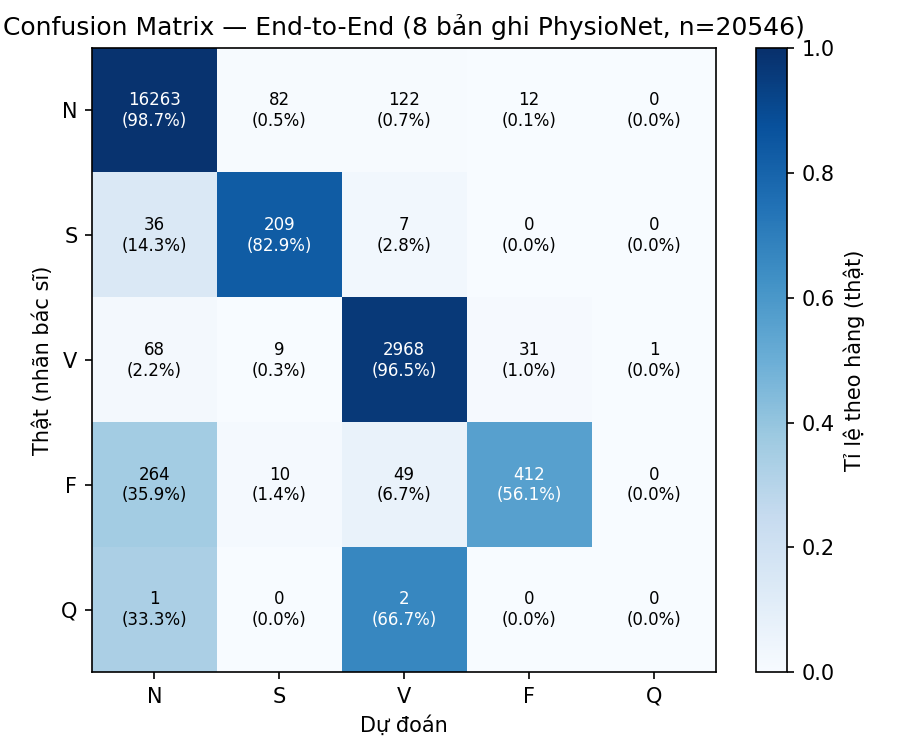

In [5]:
display(Image(filename="c2_confusion_matrix.png"))


## 5. Phát hiện đỉnh R (QRS) — Pan-Tompkins

Mỗi bản ghi MIT-BIH là 1 điểm dữ liệu — F1 so với nhãn bác sĩ (`.atr`) trên 8 bản ghi,
**F1 trung bình 97.14%**. 2 bản ghi khó nhất (207, 119) thuộc nhóm khó nhất toàn bộ MIT-BIH.


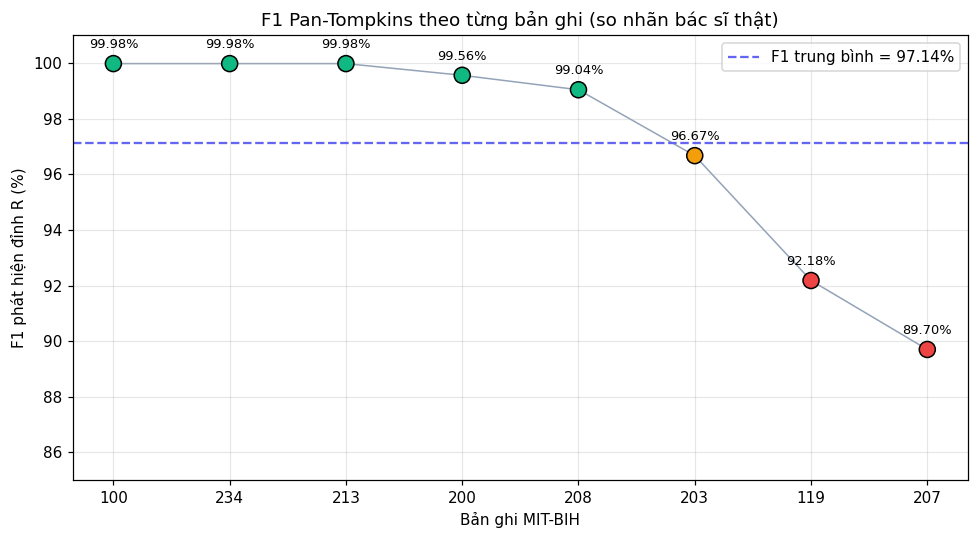

In [6]:
records = ["100", "234", "213", "200", "208", "203", "119", "207"]
f1_scores = [99.98, 99.98, 99.98, 99.56, 99.04, 96.67, 92.18, 89.70]
mean_f1 = 97.14

fig, ax = plt.subplots(figsize=(9, 5))
colors_qrs = ["#10b981" if f >= 97 else ("#f59e0b" if f >= 93 else "#ef4444") for f in f1_scores]
ax.scatter(records, f1_scores, s=110, color=colors_qrs, edgecolor="black", zorder=3)
ax.plot(records, f1_scores, color="#94a3b8", linewidth=1, zorder=1)
for r, f in zip(records, f1_scores):
    ax.annotate(f"{f:.2f}%", (r, f), textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=8.5)
ax.axhline(mean_f1, color="#6366f1", linestyle="--", label=f"F1 trung bình = {mean_f1}%")
ax.set_ylim(85, 101)
ax.set_xlabel("Bản ghi MIT-BIH")
ax.set_ylabel("F1 phát hiện đỉnh R (%)")
ax.set_title("F1 Pan-Tompkins theo từng bản ghi (so nhãn bác sĩ thật)")
ax.legend()
fig.tight_layout()
plt.show()


## 6. Xuất mô hình nhẹ — ONNX FP32 / INT8 Quantized

3 định dạng là 3 điểm dữ liệu trên cùng 1 model (ResNet1D) — đánh đổi kích thước/tốc độ/độ
chính xác. INT8 đạt mục tiêu kích thước (<700KB) nhưng **không** nhanh hơn trên CPU dev thường
(hạn chế đã biết của dynamic quantization — chỉ có lợi rõ trên phần cứng có tập lệnh INT8
chuyên dụng).


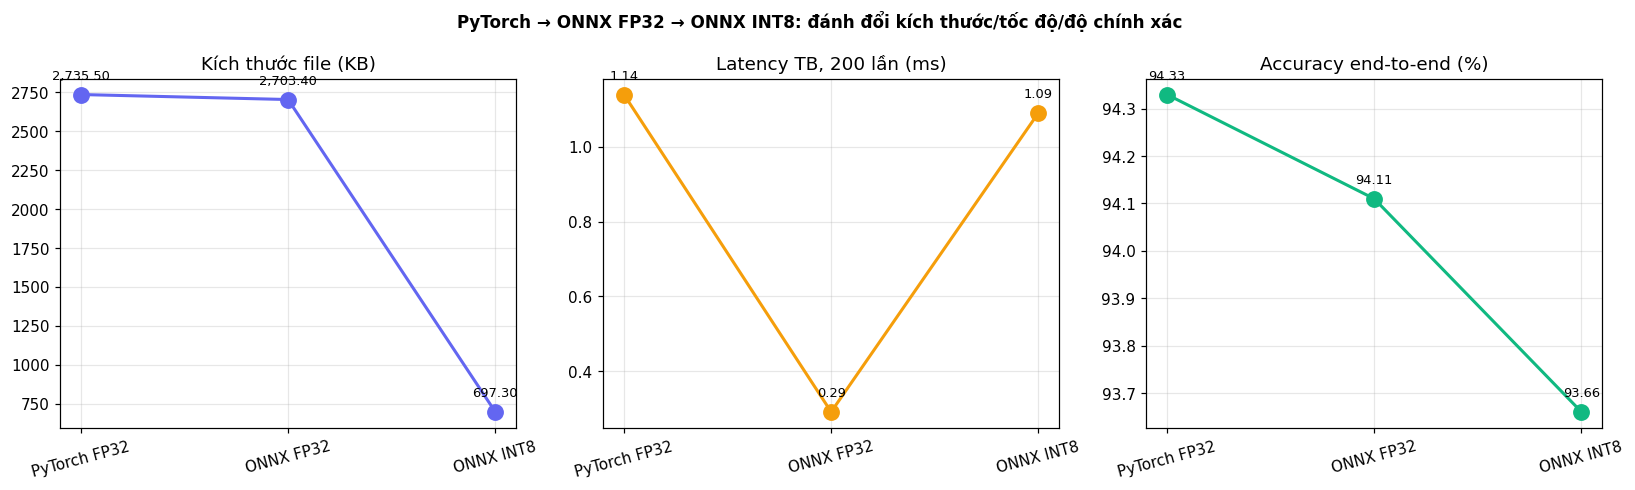

In [7]:
formats = ["PyTorch FP32", "ONNX FP32", "ONNX INT8"]
size_kb = [2735.5, 2703.4, 697.3]
latency_ms_onnx = [1.1392, 0.2918, 1.0899]
acc_e2e = [94.33, 94.11, 93.66]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = [("Kích thước file (KB)", size_kb, "#6366f1"),
           ("Latency TB, 200 lần (ms)", latency_ms_onnx, "#f59e0b"),
           ("Accuracy end-to-end (%)", acc_e2e, "#10b981")]

for ax, (title, values, color) in zip(axes, metrics):
    ax.plot(formats, values, marker="o", markersize=10, color=color, linewidth=2)
    for f, v in zip(formats, values):
        ax.annotate(f"{v:,.2f}" if v > 100 else f"{v:.2f}", (f, v),
                    textcoords="offset points", xytext=(0, 10), ha="center", fontsize=8.5)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("PyTorch → ONNX FP32 → ONNX INT8: đánh đổi kích thước/tốc độ/độ chính xác",
             fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()


## 7. Sàng lọc Rung nhĩ (AFib) — tầng rule-based riêng

Không phải 1 lớp trong model 5 lớp AAMI mà là tầng riêng (`AfibScreener`), tính điểm từ độ
không đều RR + pNN50 + RMSSD trên cửa sổ trượt 50 khoảng RR gần nhất.

**Nợ kỹ thuật cần nói thẳng (không tô hồng, không vẽ biểu đồ giả)**:
- Ngưỡng `threshold = 0.62` là **chọn tay theo trực giác**, thử hiệu chỉnh bằng AFDB thật nhưng
  môi trường mạng hạn chế chỉ tải được ~10 phút 1 bản ghi — không đủ để kết luận thống kê đáng
  tin (Youden's J ≈ 0 trên mẫu này).
- Do đó **không có** đủ dữ liệu Sensitivity/Specificity đáng tin cậy để vẽ ROC ở đây — cố tình
  không dựng biểu đồ minh hoạ giả để tránh gây hiểu nhầm là đã kiểm chứng xong.


## 8. Generalization ngoài MIT-BIH (INCART / SVDB / EDB)

4 bộ dữ liệu độc lập hoàn toàn (khác bệnh viện/thiết bị/đạo trình) — mỗi bộ là 1 điểm trên
trục X, mỗi đường là 1 chỉ số theo lớp.


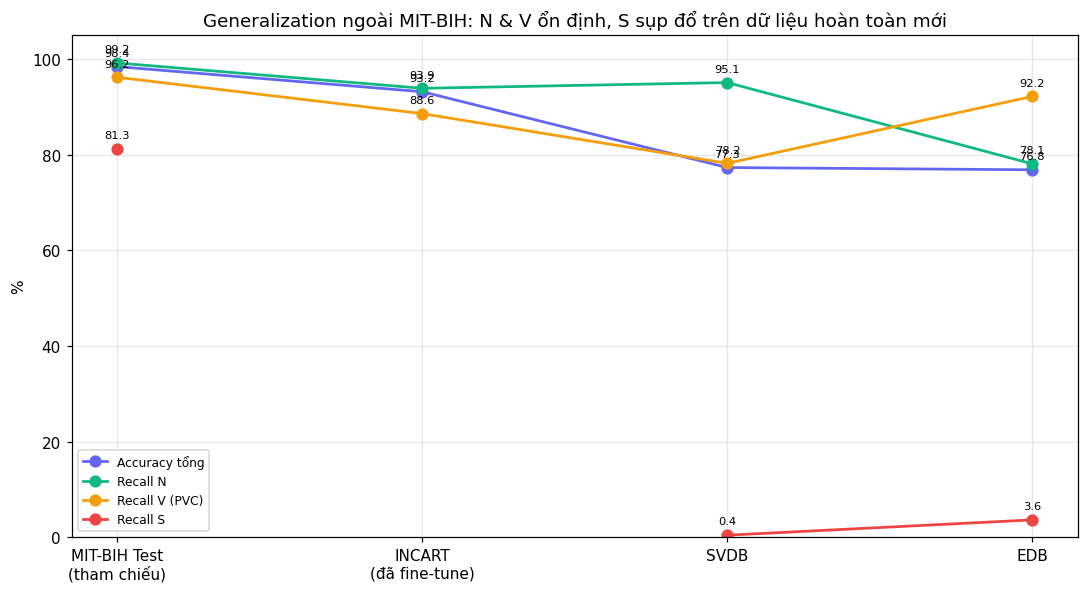

In [8]:
datasets = ["MIT-BIH Test\n(tham chiếu)", "INCART\n(đã fine-tune)", "SVDB", "EDB"]
acc_gen   = [98.43, 93.18, 77.32, 76.85]
recall_n  = [99.2, 93.9, 95.1, 78.1]
recall_v  = [96.2, 88.6, 78.2, 92.2]
recall_s  = [81.3, np.nan, 0.4, 3.6]

fig, ax = plt.subplots(figsize=(10, 5.5))
scatter_line(ax, datasets, [
    ("Accuracy tổng", acc_gen, "#6366f1"),
    ("Recall N", recall_n, "#10b981"),
    ("Recall V (PVC)", recall_v, "#f59e0b"),
    ("Recall S", recall_s, "#ef4444"),
], "Generalization ngoài MIT-BIH: N & V ổn định, S sụp đổ trên dữ liệu hoàn toàn mới",
   "%", ylim=(0, 105))
fig.tight_layout()
plt.show()


## 9. Fine-tune INCART — 3 lần thử, mỗi lần 1 bài học

Mục tiêu: cải thiện INCART **mà không tụt** 4 chỉ tiêu đề cương trên MIT-BIH. Mỗi lần thử là
1 điểm dữ liệu thật (không phải mô phỏng) — biểu đồ cho thấy rõ **lần 3 (loại lớp S khỏi
fine-tune)** là lần duy nhất đạt cả 2 mục tiêu cùng lúc.


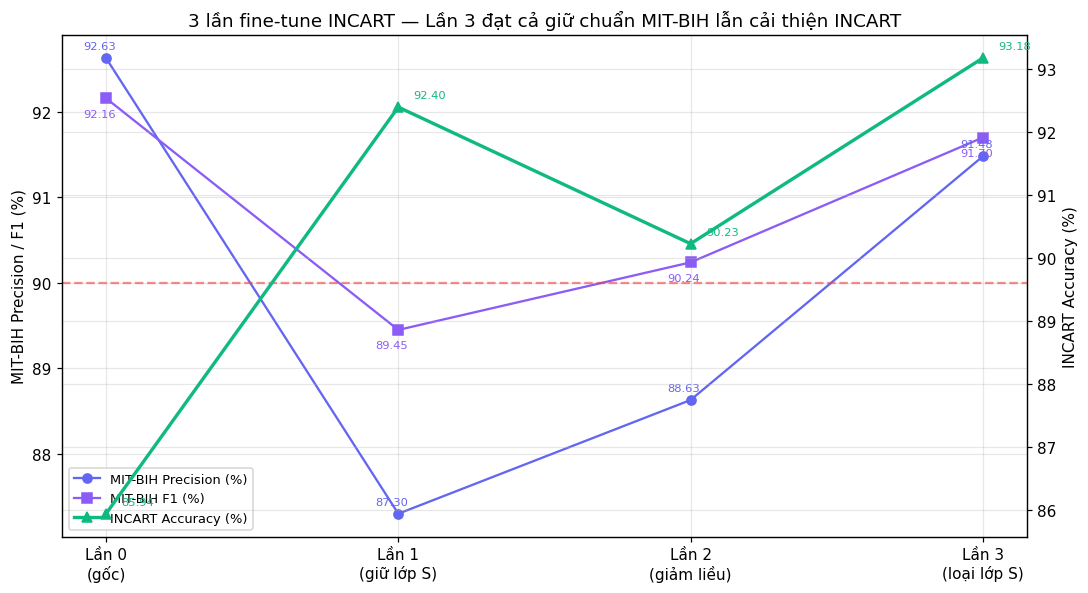

Kết luận: loại lớp S (Trên thất) khỏi tập fine-tune INCART giải quyết đúng gốc rễ —
xung đột phân phối lớp S giữa 2 nguồn dữ liệu, không phải vấn đề 'train quá tay'.


In [9]:
attempts = ["Lần 0\n(gốc)", "Lần 1\n(giữ lớp S)", "Lần 2\n(giảm liều)", "Lần 3\n(loại lớp S)"]
mitbih_precision = [92.63, 87.30, 88.63, 91.48]
mitbih_f1        = [92.16, 89.45, 90.24, 91.70]
incart_acc       = [85.94, 92.40, 90.23, 93.18]
target_precision = 90.0  # muc tieu de cuong

fig, ax1 = plt.subplots(figsize=(10, 5.5))
ax2 = ax1.twinx()

x = np.arange(len(attempts))
l1, = ax1.plot(x, mitbih_precision, marker="o", color="#6366f1", label="MIT-BIH Precision (%)")
l2, = ax1.plot(x, mitbih_f1, marker="s", color="#8b5cf6", label="MIT-BIH F1 (%)")
ax1.axhline(target_precision, color="#ef4444", linestyle="--", alpha=0.6, label="Ngưỡng mục tiêu (90%)")
l3, = ax2.plot(x, incart_acc, marker="^", color="#10b981", linewidth=2.2, label="INCART Accuracy (%)")

for xi, p, f, a in zip(x, mitbih_precision, mitbih_f1, incart_acc):
    ax1.annotate(f"{p:.2f}", (xi, p), textcoords="offset points", xytext=(-15, 6), fontsize=7.5, color="#6366f1")
    ax1.annotate(f"{f:.2f}", (xi, f), textcoords="offset points", xytext=(-15, -12), fontsize=7.5, color="#8b5cf6")
    ax2.annotate(f"{a:.2f}", (xi, a), textcoords="offset points", xytext=(10, 6), fontsize=7.5, color="#10b981")

ax1.set_xticks(x); ax1.set_xticklabels(attempts)
ax1.set_ylabel("MIT-BIH Precision / F1 (%)")
ax2.set_ylabel("INCART Accuracy (%)")
ax1.set_title("3 lần fine-tune INCART — Lần 3 đạt cả giữ chuẩn MIT-BIH lẫn cải thiện INCART")
ax1.legend(handles=[l1, l2, l3], loc="lower left", fontsize=8.5)
fig.tight_layout()
plt.show()

print("Kết luận: loại lớp S (Trên thất) khỏi tập fine-tune INCART giải quyết đúng gốc rễ —")
print("xung đột phân phối lớp S giữa 2 nguồn dữ liệu, không phải vấn đề 'train quá tay'.")


## 10. Fine-tune SVDB — 2 lần thử để sửa lớp S, đều thất bại (ghi nhận khoa học)

Mỗi epoch là 1 điểm dữ liệu thật, lấy từ log huấn luyện — cho thấy rõ **cải thiện Recall_S luôn
đi kèm cái giá làm hại Recall_V**, dù dùng 2 kỹ thuật khác nhau (fine-tune toàn mạng vs linear
probing).


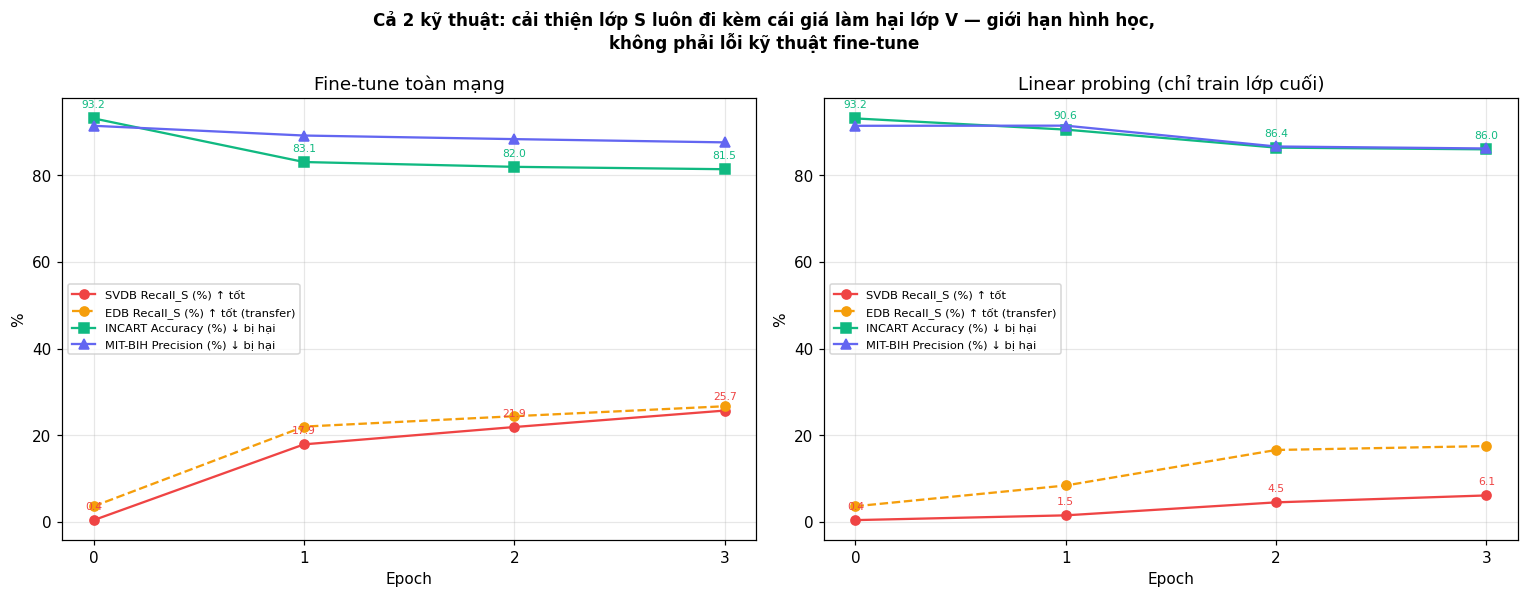

Quyết định: KHÔNG promote 2 bản fine-tune SVDB. Production giữ bản fine-tune INCART (lần 3).
Sửa triệt để cần train lại từ đầu, trộn MIT-BIH+SVDB+INCART từ vòng chia Train/Val/Test đầu tiên
— không nằm trong phạm vi đợt cải thiện này.


In [10]:
ep = [0, 1, 2, 3]

full_ft = dict(
    mitbih_prec=[91.48, 89.23, 88.40, 87.65],
    svdb_recall_s=[0.4, 17.9, 21.9, 25.7],
    incart_acc=[93.18, 83.11, 82.00, 81.45],
    edb_recall_s=[3.6, 22.0, 24.4, 26.7],
)
linear_probe = dict(
    mitbih_prec=[91.48, 91.51, 86.70, 86.24],
    svdb_recall_s=[0.4, 1.5, 4.5, 6.1],
    incart_acc=[93.18, 90.60, 86.44, 86.04],
    edb_recall_s=[3.6, 8.4, 16.6, 17.5],
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)

for ax, run, title in zip(axes, (full_ft, linear_probe),
                           ("Fine-tune toàn mạng", "Linear probing (chỉ train lớp cuối)")):
    ax.plot(ep, run["svdb_recall_s"], marker="o", color="#ef4444", label="SVDB Recall_S (%) ↑ tốt")
    ax.plot(ep, run["edb_recall_s"], marker="o", color="#f59e0b", linestyle="--", label="EDB Recall_S (%) ↑ tốt (transfer)")
    ax.plot(ep, run["incart_acc"], marker="s", color="#10b981", label="INCART Accuracy (%) ↓ bị hại")
    ax.plot(ep, run["mitbih_prec"], marker="^", color="#6366f1", label="MIT-BIH Precision (%) ↓ bị hại")
    for key, color in (("svdb_recall_s", "#ef4444"), ("incart_acc", "#10b981")):
        for xi, yi in zip(ep, run[key]):
            ax.annotate(f"{yi:.1f}", (xi, yi), textcoords="offset points", xytext=(0, 7),
                        ha="center", fontsize=7, color=color)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("%")
    ax.set_title(title)
    ax.set_xticks(ep)
    ax.legend(fontsize=7.5, loc="center left")

fig.suptitle("Cả 2 kỹ thuật: cải thiện lớp S luôn đi kèm cái giá làm hại lớp V — giới hạn hình học,\n"
             "không phải lỗi kỹ thuật fine-tune", fontsize=11, fontweight="bold")
fig.tight_layout()
plt.show()

print("Quyết định: KHÔNG promote 2 bản fine-tune SVDB. Production giữ bản fine-tune INCART (lần 3).")
print("Sửa triệt để cần train lại từ đầu, trộn MIT-BIH+SVDB+INCART từ vòng chia Train/Val/Test đầu tiên")
print("— không nằm trong phạm vi đợt cải thiện này.")


## 11. Tổng kết giới hạn đã biết (để không hứa quá tay khi bảo vệ)

| Hạng mục | Trạng thái |
|---|---|
| Model production | ResNet1D (fine-tune INCART, lần 3) |
| Accuracy nội bộ MIT-BIH | 98.51% Test / 96.62% end-to-end PhysioNet thật |
| Lớp N, V (PVC) | Generalize tốt, ổn định 78-96% trên 4 bộ dữ liệu độc lập |
| Lớp S, F | **Chưa** generalize tốt ngoài MIT-BIH (SVDB Recall_S 0.4%, EDB 3.6%) — cần train lại từ đầu với dữ liệu đa nguồn, không phải thiếu sót lần triển khai này |
| Ngưỡng AFib (0.62) | Chọn tay theo trực giác, **chưa kiểm chứng thống kê đầy đủ** — coi là gợi ý sàng lọc, không phải kết luận |
| Phạm vi thiết bị an toàn | Holter/đạo trình kiểu MLII giống MIT-BIH — đổi thiết bị khác cần fine-tune lại |
| ONNX | FP32 nhanh hơn PyTorch rõ rệt; INT8 nhỏ nhất nhưng không nhanh hơn trên CPU dev thường |

Chi tiết đầy đủ từng mục: [ai_process_summary.md](ai_process_summary.md).
